# End-to-End Retail Sales & Profitability Analysis

## 1. Project Overview

This project analyzes the retail data to help identify patterns in sales performance, profitability, customer behavior, product performance, and lastly regional results. 

The main goal is to be able to use an end-to-end analytical workflow to take raw data into actionable business insights. 

### Business Scenario 

A company wants a greater insights on what is driving sales and profitability across its products, customers, and regions. Management needs an in-more depth look that can support decisions around product performance, discounting, regional strategy, and overall profitability. 

### Business Questions 

- Which product categories, and sub-categories, contribute the most sales?
- Which products, and categories, contribute the most profit?
- Which states and regions perform best and worst?
- How does sales and profit change over time?
- How can discounts affect profitability?
- Which customer segments contribute the most sales and profit 
- Which products generate higher sales but low or negative profit?
- What business actions are able to improve overall profitability?

### Tools Used

- Excel
- SQL
- Python
- pandas
- Power BI
- GitHub

### Dataset

This analysis uses the Sample Superstore retail dataset, which includes information regarding orders, customers, products, sales, discounts, profit, dates, and geographic regions. 

### Project Workflow

**Raw Data -> Excel -> SQL -> Python -> Power BI -> Business Recommendations**

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [37]:
df = pd.read_excel("../data/sample_-_superstore.xls")

## 2. Loading Data & Quality Checks

In [39]:
df.shape

(10194, 21)

In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='str')

In [7]:
df.dtypes

Row ID                     int64
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode                    str
Customer ID                  str
Customer Name                str
Segment                      str
Country/Region               str
City                         str
State/Province               str
Postal Code               object
Region                       str
Product ID                   str
Category                     str
Sub-Category                 str
Product Name                 str
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
dtype: object

In [9]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit
count,10194.000000,10194,10194,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,2025-04-29 11:48:25.002943,2025-05-03 10:52:45.626839,228.225854,3.791838,0.155385,28.673417
min,1.000000,2023-01-03 00:00:00,2023-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,2024-05-14 00:00:00,2024-05-19 00:00:00,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,2025-06-25 00:00:00,2025-06-28 00:00:00,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,2026-05-14 00:00:00,2026-05-18 00:00:00,209.500000,5.000000,0.200000,29.297925
max,10194.000000,2026-12-30 00:00:00,2027-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000
std,2942.898656,NaN,NaN,619.906839,2.228317,0.206249,232.465115


## 3. Overall Business Performance

In [12]:
df[["Sales", "Quantity", "Profit"]].sum()

Sales       2.326534e+06
Quantity    3.865400e+04
Profit      2.922968e+05
dtype: float64

## 4. Category Performance

In [13]:
df.groupby("Category")[["Sales", "Quantity", "Profit"]].sum().sort_values("Sales", ascending=False)

,Sales,Quantity,Profit
Category,,,
Technology,839893.2790,7017,146543.3756
Furniture,754747.7613,8369,19729.9956
Office Supplies,731893.3140,23268,126023.4434


## 5. Sub-Category Profitability

In [14]:
df.groupby("Sub-Category")[["Sales", "Quantity", "Profit"]].sum().sort_values("Profit", ascending=True)

,Sales,Quantity,Profit
Sub-Category,,,
Tables,208020.1820,1261,-17753.2061
Bookcases,115361.2043,878,-3632.0736
Supplies,46725.4980,653,-1171.3945
Fasteners,8532.2400,980,2428.6358
Machines,189925.0310,442,3461.9769
Labels,12695.0420,1410,5572.7780
Art,27659.0140,3092,6653.1962
Envelopes,16528.3620,914,6988.0247
Furnishings,95598.1260,3799,13891.7430


## 6. Discount & Profitability Analysis

In [15]:
df.groupby("Discount")[["Sales", "Quantity", "Profit"]].sum().sort_index()

,Sales,Quantity,Profit
Discount,,,
0.00,1.105324e+06,18770,326718.5872
0.10,5.495250e+04,377,9099.9700
0.15,2.755852e+04,198,1418.9915
0.20,7.739394e+05,13856,91079.9517
0.30,1.044741e+05,855,-10513.4456
0.32,1.449346e+04,105,-2391.1377
0.40,1.164978e+05,789,-23086.3742
0.45,5.484974e+03,45,-2493.1111
0.50,5.891854e+04,241,-20506.4281


In [16]:
df.groupby("Sub-Category")[["Discount", "Profit"]].mean().sort_values("Discount", ascending=False)

,Discount,Profit
Sub-Category,,
Binders,0.369057,20.301098
Machines,0.304274,29.589546
Tables,0.258129,-54.457687
Bookcases,0.215259,-15.655490
Chairs,0.169243,42.939325
Appliances,0.164557,38.669798
Copiers,0.157143,801.341950
Phones,0.152602,49.890173
Furnishings,0.138057,13.767833


In [17]:
df.groupby("Product Name")[["Sales", "Quantity", "Discount", "Profit"]].sum().sort_values("Profit").head(10)

,Sales,Quantity,Discount,Profit
Product Name,,,,
Cubify CubeX 3D Printer Double Head Print,11099.963,9,1.60,-8879.9704
Lexmark MX611dhe Monochrome Laser Printer,16829.901,18,1.60,-4589.9730
Cubify CubeX 3D Printer Triple Head Print,7999.980,4,0.50,-3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.640,27,1.40,-2876.1156
Bush Advantage Collection Racetrack Conference Table,9544.725,33,2.45,-1934.3976
GBC DocuBind P400 Electric Binding System,17965.068,27,2.70,-1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,6,0.50,-1811.0784
Martin Yale Chadless Opener Electric Letter Opener,16656.200,22,0.60,-1299.1836
Balt Solid Wood Round Tables,6518.754,19,0.80,-1201.0581


In [18]:
df.groupby("Discount")["Profit"].mean().sort_index()

Discount
0.00     66.338799
0.10     94.791354
0.15     27.288298
0.20     24.576350
0.30    -45.710633
0.32    -88.560656
0.40   -111.528378
0.45   -226.646464
0.50   -310.703456
0.60    -41.371458
0.70    -95.048521
0.80   -101.545745
Name: Profit, dtype: float64

## 7. Regional Performance

In [19]:
df.groupby("Region")[["Sales", "Quantity", "Profit"]].sum().sort_values("Profit", ascending=False)

,Sales,Quantity,Profit
Region,,,
West,739813.6085,12466,110798.8170
East,691828.1680,11159,94883.2603
South,391721.9050,6209,46749.4303
Central,503170.6728,8820,39865.3070


## 8. Customer Segment Performance

In [20]:
df.groupby("Segment")[["Sales", "Quantity", "Profit"]].sum().sort_values("Profit", ascending=False)

,Sales,Quantity,Profit
Segment,,,
Consumer,1.170660e+06,19844,136371.4463
Corporate,7.158061e+05,11898,94249.6400
Home Office,4.400684e+05,6912,61675.7283


In [21]:
segment_performance = df.groupby("Segment")[["Sales", "Profit"]].sum()

segment_performance["Profit Margin"] = (
    segment_performance["Profit"] / segment_performance["Sales"] * 100
)

segment_performance.sort_values("Profit Margin", ascending=False)

,Sales,Profit,Profit Margin
Segment,,,
Home Office,4.400684e+05,61675.7283,14.015031
Corporate,7.158061e+05,94249.6400,13.166923
Consumer,1.170660e+06,136371.4463,11.649110


## 9. State-level Performance 

In [40]:
state_performance = df.groupby("State/Province")[["Sales", "Profit"]].sum()

state_performance.sort_values("Profit").head(10)

,Sales,Profit
State/Province,,
Texas,170188.0458,-25729.3563
Ohio,78258.1360,-16971.3766
Pennsylvania,116511.9140,-15559.9603
Illinois,80166.1010,-12607.8870
North Carolina,55603.1640,-7490.9122
Colorado,32108.1180,-6527.8579
Tennessee,30661.8730,-5341.6936
Arizona,35282.0010,-3427.9246
Florida,89473.7080,-3399.3017


In [41]:
state_performance["Profit Margin"] = (
    state_performance["Profit"] / state_performance["Sales"] * 100
)

state_performance.sort_values("Profit Margin").head(10)

,Sales,Profit,Profit Margin
State/Province,,,
New Brunswick,225.6960,-74.1416,-32.850206
Ohio,78258.1360,-16971.3766,-21.686405
Colorado,32108.1180,-6527.8579,-20.330864
Tennessee,30661.8730,-5341.6936,-17.421289
Illinois,80166.1010,-12607.8870,-15.727205
Texas,170188.0458,-25729.3563,-15.118192
Nova Scotia,382.1440,-52.7420,-13.801604
North Carolina,55603.1640,-7490.9122,-13.472097
Pennsylvania,116511.9140,-15559.9603,-13.354823


In [24]:
state_performance.sort_values("Profit", ascending=False).head(10)

,Sales,Profit,Profit Margin
State/Province,,,
California,457687.6315,76381.3871,16.688541
New York,310876.2710,74038.5486,23.816082
Washington,138641.2700,33402.6517,24.092863
Michigan,76269.6140,24463.1876,32.074618
Virginia,70636.7200,18597.9504,26.329012
Indiana,53555.3600,18382.9363,34.325110
Georgia,49095.8400,16250.0433,33.098615
Kentucky,36591.7500,11199.6966,30.607163
Minnesota,29863.1500,10823.1874,36.242618


## 10. State and Category Deep Dive

In [25]:
state_category = df.groupby(
    ["State/Province", "Category"]
)[["Sales", "Profit"]].sum()

state_category.sort_values("Profit").head(15)

Sales      Profit
State/Province Category                               
Texas          Office Supplies  44490.5300 -18584.6434
Ohio           Technology       35675.9920 -12649.9401
Texas          Furniture        60593.2918 -10436.1419
Illinois       Furniture        28274.5220  -9076.2894
               Office Supplies  19907.9060  -8354.1568
Pennsylvania   Furniture        39354.9310  -7196.7199
               Office Supplies  34941.7140  -5172.0188
Ohio           Furniture        24199.1450  -4206.3212
North Carolina Technology       26083.1190  -3583.3040
               Furniture        15155.4840  -3486.4633
Colorado       Technology       10966.3290  -3471.5845
Tennessee      Office Supplies  12347.8580  -3199.0982
Pennsylvania   Technology       42215.2690  -3191.2216
Arizona        Furniture        13525.2910  -2744.9228
Colorado       Furniture        13243.0370  -2683.1342

In [26]:
df[
    (df["State/Province"] == "Texas") &
    (df["Category"] == "Office Supplies")
].groupby("Sub-Category")[["Sales", "Quantity", "Profit"]].sum().sort_values("Profit")

,Sales,Quantity,Profit
Sub-Category,,,
Binders,9042.676,626,-14705.0738
Appliances,2407.814,159,-6147.2225
Supplies,4516.760,65,-837.2795
Storage,15723.584,309,-763.7054
Fasteners,332.464,108,80.7357
Labels,583.600,96,200.4020
Art,2369.528,259,316.3538
Envelopes,2530.648,105,848.1760
Paper,6983.456,572,2422.9703


In [27]:
df[
    (df["State/Province"] == "Texas") &
    (df["Sub-Category"] == "Binders")
][["Sales", "Quantity", "Discount", "Profit"]].sum()

Sales        9042.6760
Quantity      626.0000
Discount      122.4000
Profit     -14705.0738
dtype: float64

In [28]:
df[
    (df["State/Province"] == "Texas") &
    (df["Sub-Category"] == "Binders")
]["Discount"].mean()

np.float64(0.7999999999999999)

In [29]:
df[df["Sub-Category"] == "Binders"].groupby("State/Province")[["Sales", "Discount", "Profit"]].mean().sort_values("Profit")

,Sales,Discount,Profit
State/Province,,,
Tennessee,177.518690,0.700000,-125.376486
Texas,59.102458,0.800000,-96.111593
Illinois,56.731825,0.800000,-90.054053
North Carolina,71.175583,0.700000,-55.772928
Arizona,62.438657,0.700000,-47.049954
Pennsylvania,63.939367,0.700000,-46.642602
Florida,55.082060,0.700000,-41.204931
Ohio,26.261466,0.700000,-19.187234
Oregon,20.076000,0.700000,-14.195793


In [30]:
subcategory_discount = df.groupby("Sub-Category")[["Discount", "Profit"]].mean()

subcategory_discount["Profit Margin"] = (
    df.groupby("Sub-Category")["Profit"].sum()
    / df.groupby("Sub-Category")["Sales"].sum()
    * 100
)

subcategory_discount.sort_values("Discount", ascending=False)

,Discount,Profit,Profit Margin
Sub-Category,,,
Binders,0.369057,20.301098,15.155708
Machines,0.304274,29.589546,1.822812
Tables,0.258129,-54.457687,-8.534367
Bookcases,0.215259,-15.655490,-3.148436
Chairs,0.169243,42.939325,8.107834
Appliances,0.164557,38.669798,16.938310
Copiers,0.157143,801.341950,37.211071
Phones,0.152602,49.890173,13.575961
Furnishings,0.138057,13.767833,14.531397


## 11. Product Performance

In [31]:
product_performance = df.groupby("Product Name")[["Sales", "Quantity", "Profit"]].sum()

product_performance.sort_values(
    ["Sales", "Profit"],
    ascending=False
).head(10)

,Sales,Quantity,Profit
Product Name,,,
Canon imageCLASS 2200 Advanced Copier,61599.824,20,2.519993e+04
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,31,7.753039e+03
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,6,-1.811078e+03
HON 5400 Series Task Chairs for Big and Tall,21870.576,39,3.410605e-13
GBC DocuBind TL300 Electric Binding System,19823.479,37,2.233505e+03
GBC Ibimaster 500 Manual ProClick Binding System,19024.500,48,7.609800e+02
Hewlett Packard LaserJet 3310 Copier,18839.686,38,6.983884e+03
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,12,4.094977e+03
GBC DocuBind P400 Electric Binding System,17965.068,27,-1.878166e+03


In [32]:
product_performance.sort_values("Profit", ascending=False).head(10)

,Sales,Quantity,Profit
Product Name,,,
Canon imageCLASS 2200 Advanced Copier,61599.824,20,25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,31,7753.0390
Hewlett Packard LaserJet 3310 Copier,18839.686,38,6983.8836
Canon PC1060 Personal Laser Copier,11619.834,19,4570.9347
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,12,4094.9766
Ativa V4110MDD Micro-Cut Shredder,7699.890,11,3772.9461
"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890,11,3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System,9367.290,24,3696.2820
Ibico EPK-21 Electric Binding System,15875.916,13,3345.2823


In [33]:
df.sort_values("Profit").head(10)[
    ["Order ID", "Product Name", "Category", "Sub-Category",
     "Sales", "Quantity", "Discount", "Profit"]
]

,Order ID,Product Name,Category,Sub-Category,Sales,Quantity,Discount,Profit
6398,US-2025-108196,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,4499.985,5,0.7,-6599.9780
9318,US-2026-168116,Cubify CubeX 3D Printer Triple Head Print,Technology,Machines,7999.980,4,0.5,-3839.9904
821,US-2023-169019,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,2177.584,8,0.8,-3701.8928
7441,US-2026-134845,Lexmark MX611dhe Monochrome Laser Printer,Technology,Machines,2549.985,5,0.7,-3399.9800
9845,US-2026-122714,Ibico EPK-21 Electric Binding System,Office Supplies,Binders,1889.990,5,0.8,-2929.4845
4037,US-2024-147830,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,1799.994,2,0.7,-2639.9912
9557,US-2026-131254,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,Binders,1525.188,6,0.8,-2287.7820
2108,US-2024-116638,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,Tables,4297.644,13,0.4,-1862.3124
4570,US-2025-130946,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,1088.792,4,0.8,-1850.9464
226,US-2023-145317,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,22638.480,6,0.5,-1811.0784


## 12. Loss-Making Transactions

In [34]:
loss_transactions = df[df["Profit"] < 0]

print("Loss-making transactions:", len(loss_transactions))
print("Total loss:", loss_transactions["Profit"].sum())
print("Average loss per transaction:", loss_transactions["Profit"].mean())

Loss-making transactions: 1901
Total loss: -157038.9302
Average loss per transaction: -82.60859032088375


In [35]:
discount_performance = df.groupby("Discount")[["Sales", "Profit"]].sum()

discount_performance["Profit Margin"] = (
    discount_performance["Profit"]
    / discount_performance["Sales"]
    * 100
)

discount_performance

,Sales,Profit,Profit Margin
Discount,,,
0.00,1.105324e+06,326718.5872,29.558632
0.10,5.495250e+04,9099.9700,16.559702
0.15,2.755852e+04,1418.9915,5.149012
0.20,7.739394e+05,91079.9517,11.768357
0.30,1.044741e+05,-10513.4456,-10.063211
0.32,1.449346e+04,-2391.1377,-16.498047
0.40,1.164978e+05,-23086.3742,-19.817012
0.45,5.484974e+03,-2493.1111,-45.453472
0.50,5.891854e+04,-20506.4281,-34.804712


In [36]:
df.shape

(10194, 21)

## 13. Data Visualizations

In [45]:
%pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 56.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 99.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 85.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━ 3/7 [fonttools]  WARNING: The scripts fonttools, pyftmerge, pyftsubset and ttx are installed in '/Library/Frameworks/Python.framework/Versions/3.14/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [42]:
category_visual = df.groupby("Category")[["Sales", "Profit"]].sum()
category_visual

,Sales,Profit
Category,,
Furniture,754747.7613,19729.9956
Office Supplies,731893.3140,126023.4434
Technology,839893.2790,146543.3756


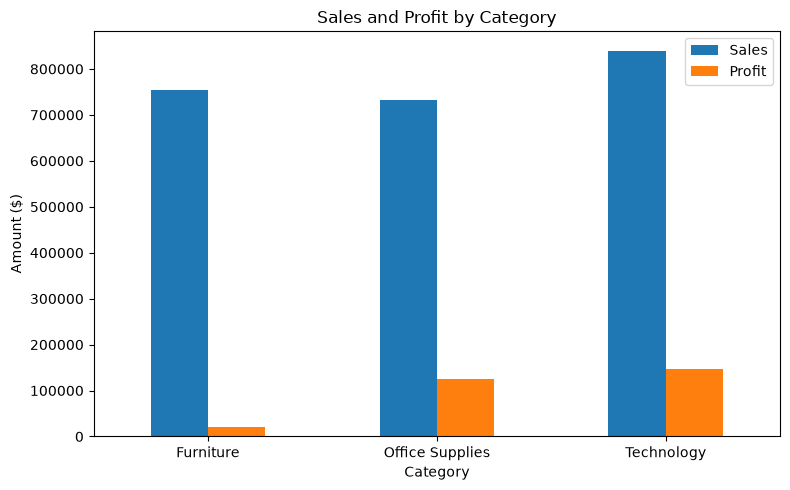

In [47]:
category_visual.plot(
    kind="bar",
    figsize=(8, 5),
    title="Sales and Profit by Category"
)

plt.ylabel("Amount ($)")
plt.xlabel("Category")
plt.xticks(rotation=0)
plt.tight_layout()

## Category Profitability 

In [48]:
category_margin = df.groupby("Category")[["Sales", "Profit"]].sum()

category_margin["Profit Margin"] = (
    category_margin["Profit"] / category_margin["Sales"] * 100
)

category_margin.sort_values("Profit Margin", ascending=False)

,Sales,Profit,Profit Margin
Category,,,
Technology,839893.2790,146543.3756,17.447857
Office Supplies,731893.3140,126023.4434,17.218827
Furniture,754747.7613,19729.9956,2.614118


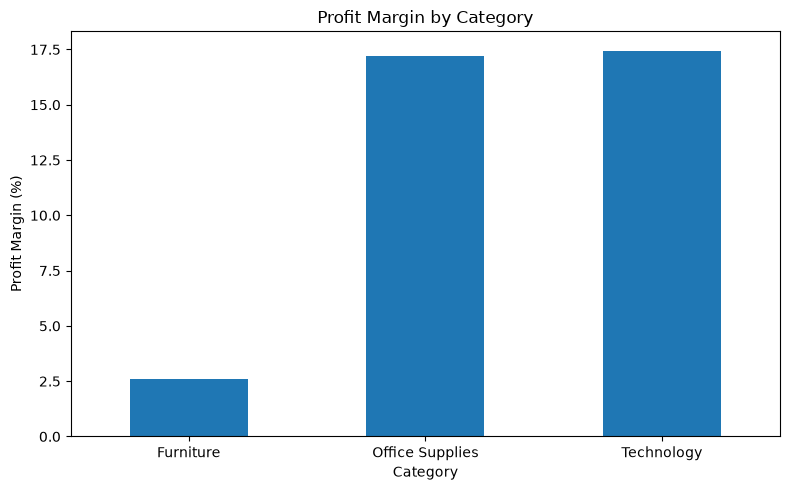

In [49]:
category_margin["Profit Margin"].plot(
    kind="bar",
    figsize=(8, 5),
    title="Profit Margin by Category"
)

plt.ylabel("Profit Margin (%)")
plt.xlabel("Category")
plt.xticks(rotation=0)
plt.tight_layout()

### Sub-Category Profitability

In [50]:
subcategory_visual = df.groupby("Sub-Category")[["Sales", "Profit"]].sum()

subcategory_visual["Profit Margin"] = (
    subcategory_visual["Profit"] / subcategory_visual["Sales"] * 100
)

subcategory_visual.sort_values("Profit", ascending=True)

,Sales,Profit,Profit Margin
Sub-Category,,,
Tables,208020.1820,-17753.2061,-8.534367
Bookcases,115361.2043,-3632.0736,-3.148436
Supplies,46725.4980,-1171.3945,-2.506971
Fasteners,8532.2400,2428.6358,28.464223
Machines,189925.0310,3461.9769,1.822812
Labels,12695.0420,5572.7780,43.897279
Art,27659.0140,6653.1962,24.054351
Envelopes,16528.3620,6988.0247,42.278991
Furnishings,95598.1260,13891.7430,14.531397


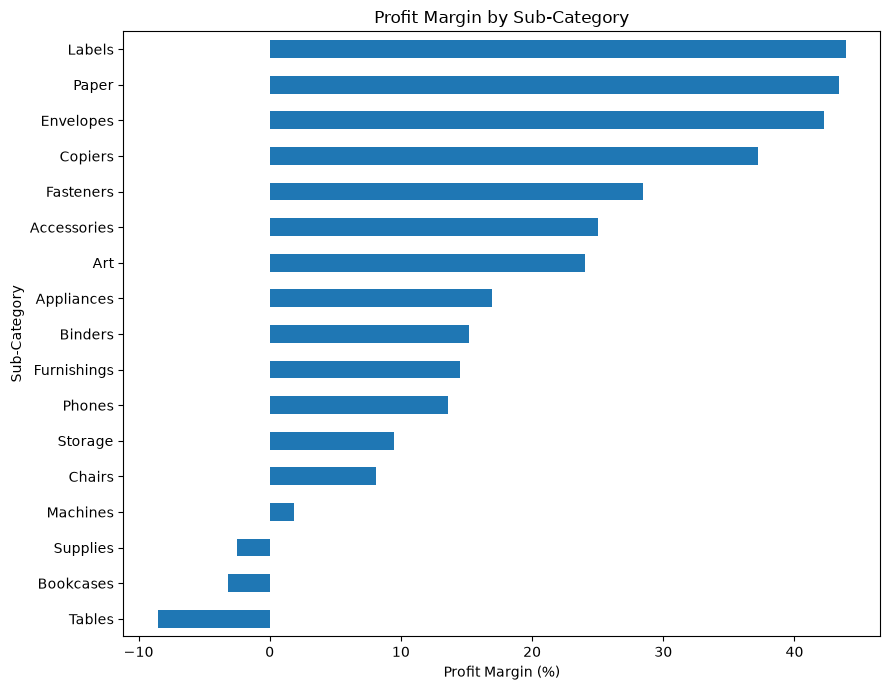

In [51]:
subcategory_visual["Profit Margin"].sort_values().plot(
    kind="barh",
    figsize=(9, 7),
    title="Profit Margin by Sub-Category"
)

plt.xlabel("Profit Margin (%)")
plt.ylabel("Sub-Category")
plt.tight_layout()

### Discount & Profitability

In [52]:
discount_visual = df.groupby("Discount")[["Sales", "Profit"]].sum()

discount_visual["Profit Margin"] = (
    discount_visual["Profit"] / discount_visual["Sales"] * 100
)

discount_visual

,Sales,Profit,Profit Margin
Discount,,,
0.00,1.105324e+06,326718.5872,29.558632
0.10,5.495250e+04,9099.9700,16.559702
0.15,2.755852e+04,1418.9915,5.149012
0.20,7.739394e+05,91079.9517,11.768357
0.30,1.044741e+05,-10513.4456,-10.063211
0.32,1.449346e+04,-2391.1377,-16.498047
0.40,1.164978e+05,-23086.3742,-19.817012
0.45,5.484974e+03,-2493.1111,-45.453472
0.50,5.891854e+04,-20506.4281,-34.804712


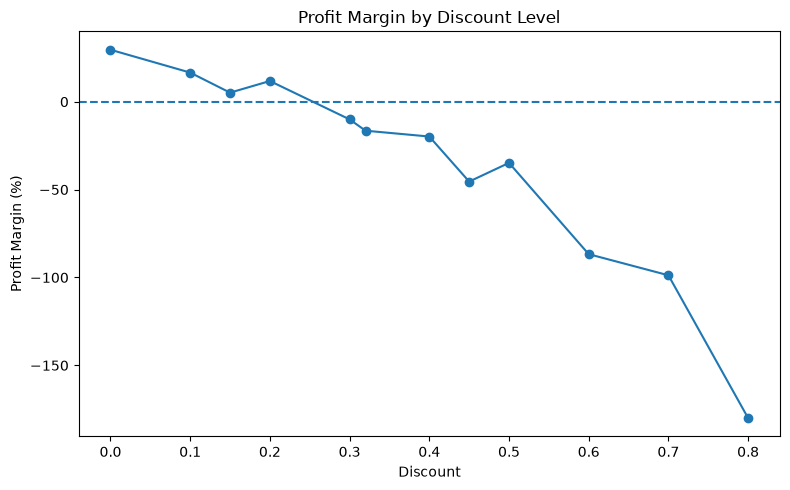

In [53]:
discount_visual["Profit Margin"].plot(
    kind="line",
    marker="o",
    figsize=(8, 5),
    title="Profit Margin by Discount Level"
)

plt.axhline(0, linestyle="--")
plt.xlabel("Discount")
plt.ylabel("Profit Margin (%)")
plt.tight_layout()

### Regional Performance

In [54]:
region_visual = df.groupby("Region")[["Sales", "Profit"]].sum()

region_visual["Profit Margin"] = (
    region_visual["Profit"] / region_visual["Sales"] * 100
)

region_visual.sort_values("Profit Margin", ascending=False)

,Sales,Profit,Profit Margin
Region,,,
West,739813.6085,110798.8170,14.976585
East,691828.1680,94883.2603,13.714859
South,391721.9050,46749.4303,11.934342
Central,503170.6728,39865.3070,7.922820


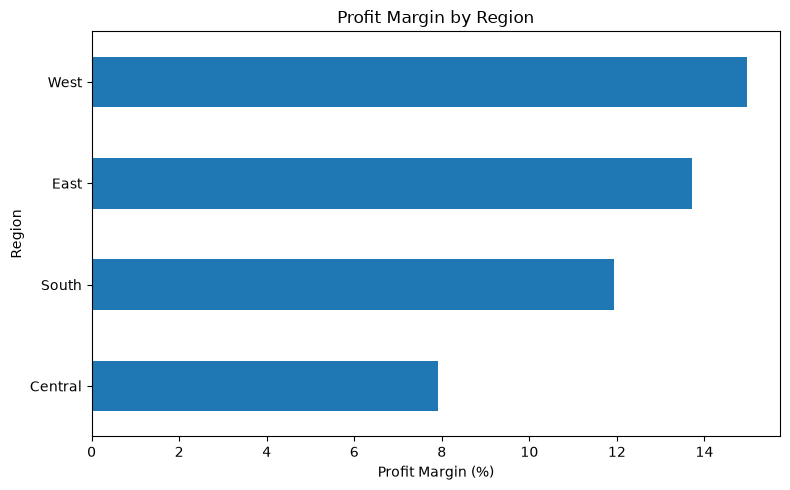

In [55]:
region_visual["Profit Margin"].sort_values().plot(
    kind="barh",
    figsize=(8, 5),
    title="Profit Margin by Region"
)

plt.xlabel("Profit Margin (%)")
plt.ylabel("Region")
plt.tight_layout()

### Customer Segment Performance

In [56]:
segment_visual = df.groupby("Segment")[["Sales", "Profit"]].sum()

segment_visual["Profit Margin"] = (
    segment_visual["Profit"] / segment_visual["Sales"] * 100
)

segment_visual.sort_values("Profit Margin", ascending=False)

,Sales,Profit,Profit Margin
Segment,,,
Home Office,4.400684e+05,61675.7283,14.015031
Corporate,7.158061e+05,94249.6400,13.166923
Consumer,1.170660e+06,136371.4463,11.649110


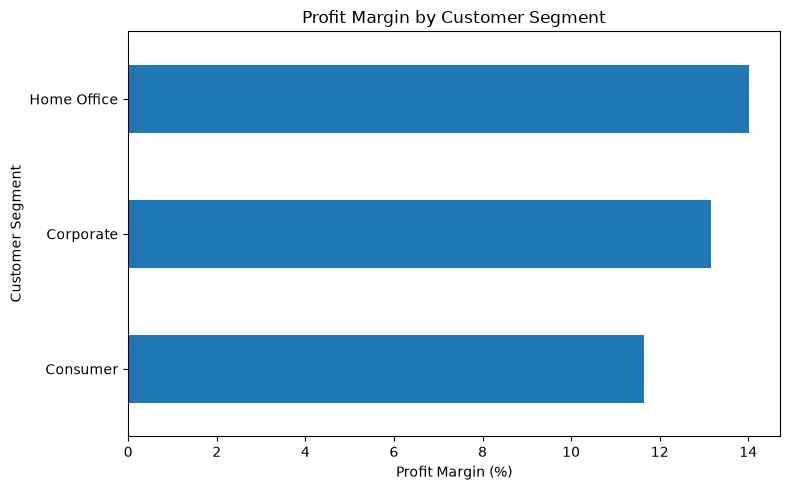

In [57]:
segment_visual["Profit Margin"].sort_values().plot(
    kind="barh",
    figsize=(8, 5),
    title="Profit Margin by Customer Segment"
)

plt.xlabel("Profit Margin (%)")
plt.ylabel("Customer Segment")
plt.tight_layout()

### State-level Performance

In [58]:
state_visual = df.groupby("State/Province")[["Sales", "Profit"]].sum()

state_visual["Profit Margin"] = (
    state_visual["Profit"] / state_visual["Sales"] * 100
)

state_visual.sort_values("Profit", ascending=True).head(10)

,Sales,Profit,Profit Margin
State/Province,,,
Texas,170188.0458,-25729.3563,-15.118192
Ohio,78258.1360,-16971.3766,-21.686405
Pennsylvania,116511.9140,-15559.9603,-13.354823
Illinois,80166.1010,-12607.8870,-15.727205
North Carolina,55603.1640,-7490.9122,-13.472097
Colorado,32108.1180,-6527.8579,-20.330864
Tennessee,30661.8730,-5341.6936,-17.421289
Arizona,35282.0010,-3427.9246,-9.715789
Florida,89473.7080,-3399.3017,-3.799219


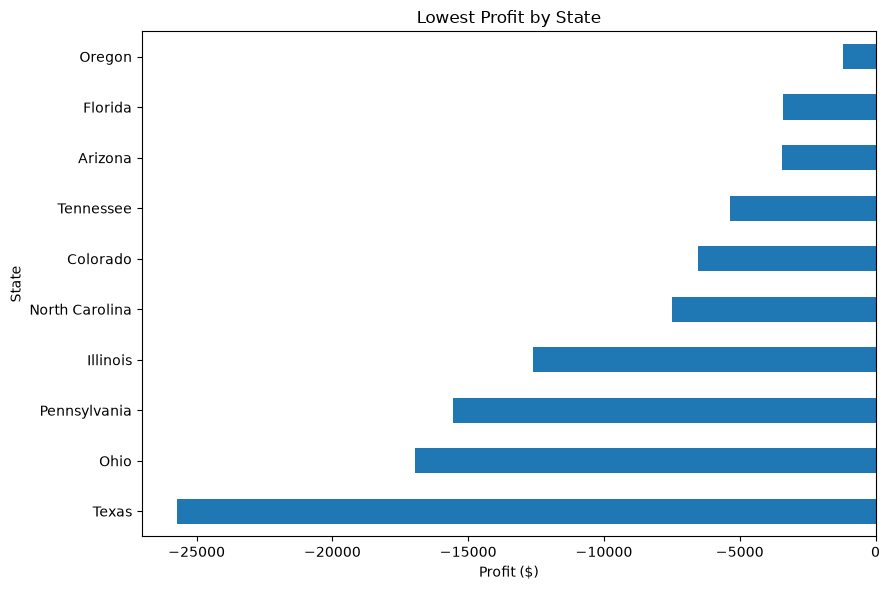

In [59]:
state_visual["Profit"].sort_values().head(10).plot(
    kind="barh",
    figsize=(9, 6),
    title="Lowest Profit by State"
)

plt.xlabel("Profit ($)")
plt.ylabel("State")
plt.tight_layout()

In [60]:
state_category_visual = df.groupby(
    ["State/Province", "Category"]
)[["Sales", "Profit"]].sum()

state_category_visual.sort_values("Profit").head(15)

Sales      Profit
State/Province Category                               
Texas          Office Supplies  44490.5300 -18584.6434
Ohio           Technology       35675.9920 -12649.9401
Texas          Furniture        60593.2918 -10436.1419
Illinois       Furniture        28274.5220  -9076.2894
               Office Supplies  19907.9060  -8354.1568
Pennsylvania   Furniture        39354.9310  -7196.7199
               Office Supplies  34941.7140  -5172.0188
Ohio           Furniture        24199.1450  -4206.3212
North Carolina Technology       26083.1190  -3583.3040
               Furniture        15155.4840  -3486.4633
Colorado       Technology       10966.3290  -3471.5845
Tennessee      Office Supplies  12347.8580  -3199.0982
Pennsylvania   Technology       42215.2690  -3191.2216
Arizona        Furniture        13525.2910  -2744.9228
Colorado       Furniture        13243.0370  -2683.1342

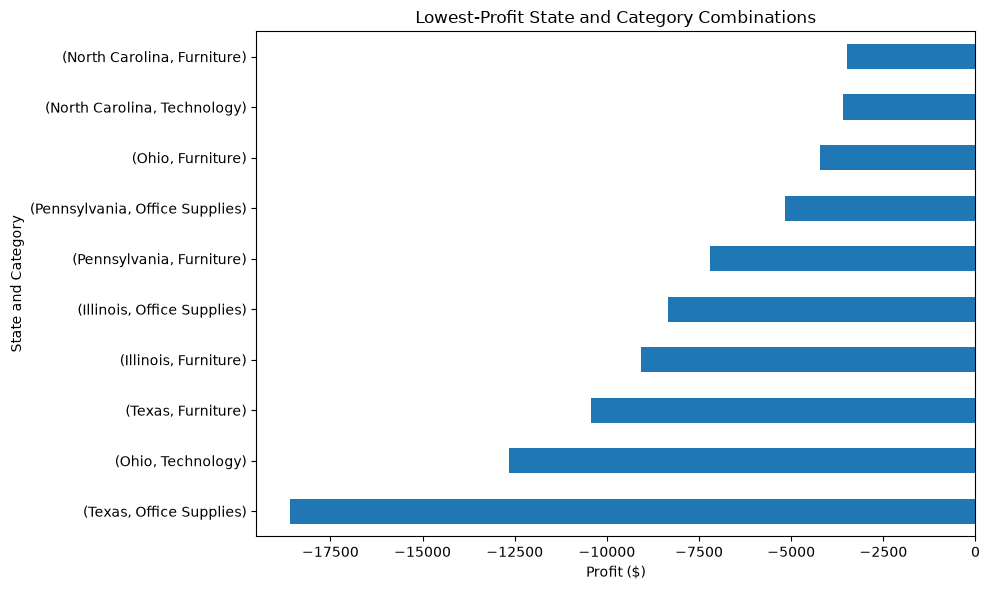

In [61]:
state_category_visual.sort_values("Profit").head(10)["Profit"].plot(
    kind="barh",
    figsize=(10, 6),
    title="Lowest-Profit State and Category Combinations"
)

plt.xlabel("Profit ($)")
plt.ylabel("State and Category")
plt.tight_layout()

### Product Performance

In [62]:
product_visual = df.groupby("Product Name")[["Sales", "Quantity", "Profit"]].sum()

product_visual.sort_values("Profit", ascending=False).head(10)

,Sales,Quantity,Profit
Product Name,,,
Canon imageCLASS 2200 Advanced Copier,61599.824,20,25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,31,7753.0390
Hewlett Packard LaserJet 3310 Copier,18839.686,38,6983.8836
Canon PC1060 Personal Laser Copier,11619.834,19,4570.9347
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,12,4094.9766
Ativa V4110MDD Micro-Cut Shredder,7699.890,11,3772.9461
"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890,11,3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System,9367.290,24,3696.2820
Ibico EPK-21 Electric Binding System,15875.916,13,3345.2823


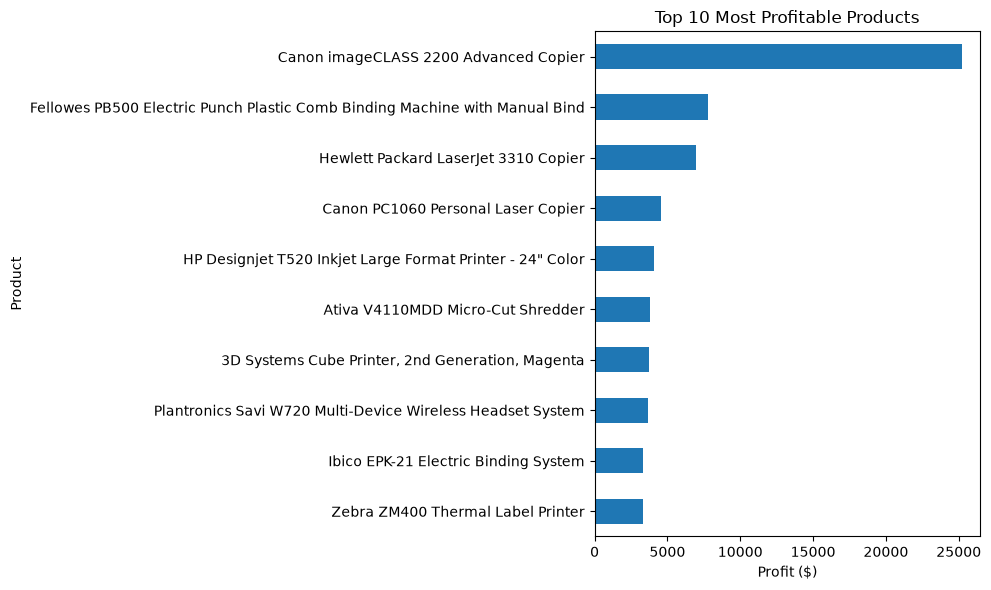

In [63]:
product_visual["Profit"].sort_values().tail(10).plot(
    kind="barh",
    figsize=(10, 6),
    title="Top 10 Most Profitable Products"
)

plt.xlabel("Profit ($)")
plt.ylabel("Product")
plt.tight_layout()

In [64]:
product_visual["Profit"].sort_values().head(10)

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64

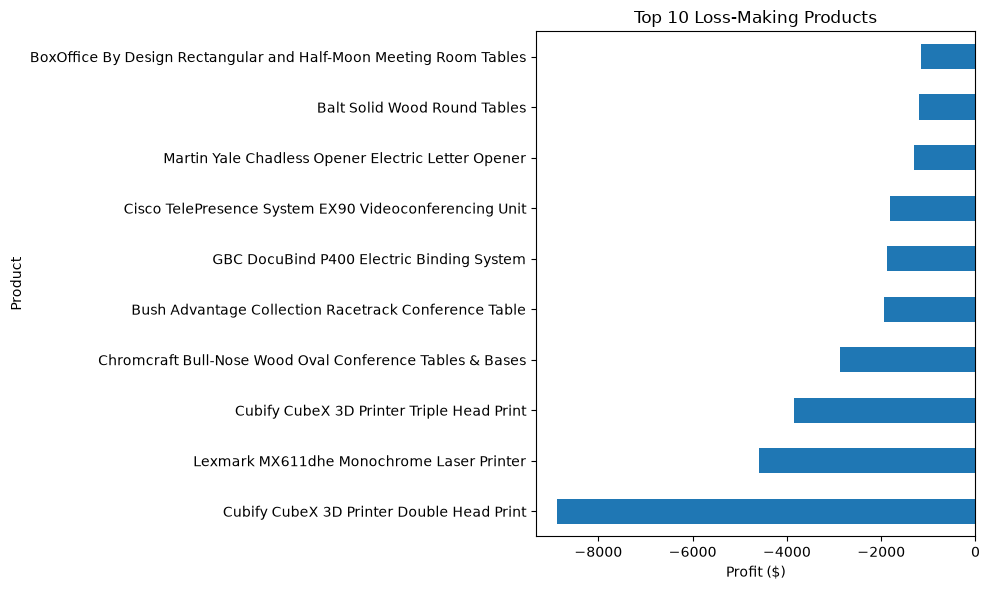

In [65]:
product_visual["Profit"].sort_values().head(10).plot(
    kind="barh",
    figsize=(10, 6),
    title="Top 10 Loss-Making Products"
)

plt.xlabel("Profit ($)")
plt.ylabel("Product")
plt.tight_layout()

### Loss-Making Transactions

In [66]:
loss_transactions = df[df["Profit"] < 0]

loss_transactions.shape

(1901, 21)

In [67]:
loss_transactions["Profit"].sum()

np.float64(-157038.9302)

In [68]:
loss_transactions["Profit"].mean()

np.float64(-82.60859032088375)

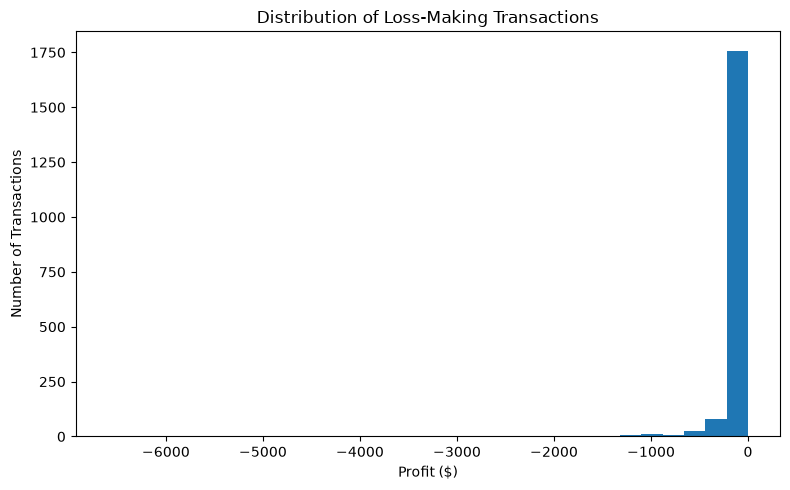

In [69]:
loss_transactions["Profit"].plot(
    kind="hist",
    bins=30,
    figsize=(8, 5),
    title="Distribution of Loss-Making Transactions"
)

plt.xlabel("Profit ($)")
plt.ylabel("Number of Transactions")
plt.tight_layout()

### Sales and Profit Over Time

In [70]:
monthly_performance = df.groupby(
    df["Order Date"].dt.to_period("M")
)[["Sales", "Profit"]].sum()

monthly_performance.head()

,Sales,Profit
Order Date,,
2023-01,14518.055,2539.3907
2023-02,4519.892,862.3084
2023-03,56933.909,693.4499
2023-04,28295.345,3488.8352
2023-05,26319.767,3196.3918


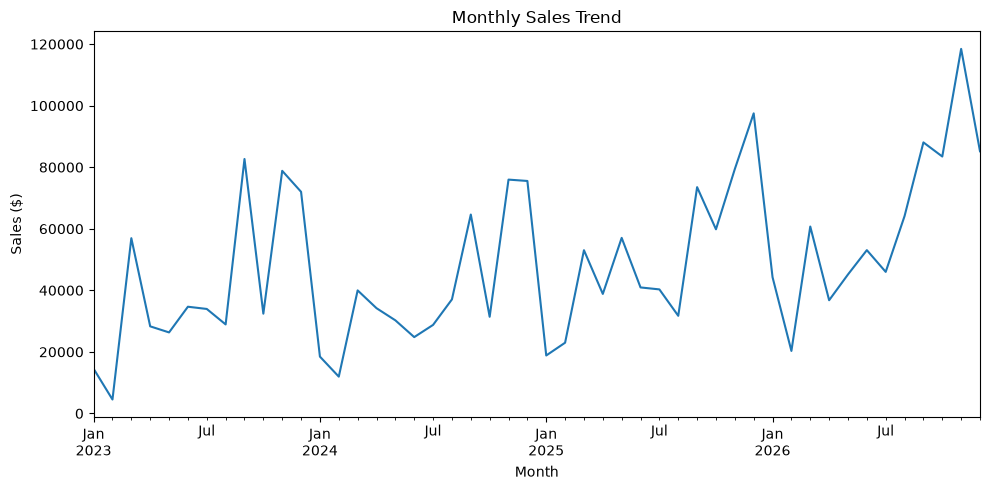

In [71]:
monthly_performance["Sales"].plot(
    kind="line",
    figsize=(10, 5),
    title="Monthly Sales Trend"
)

plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.tight_layout()

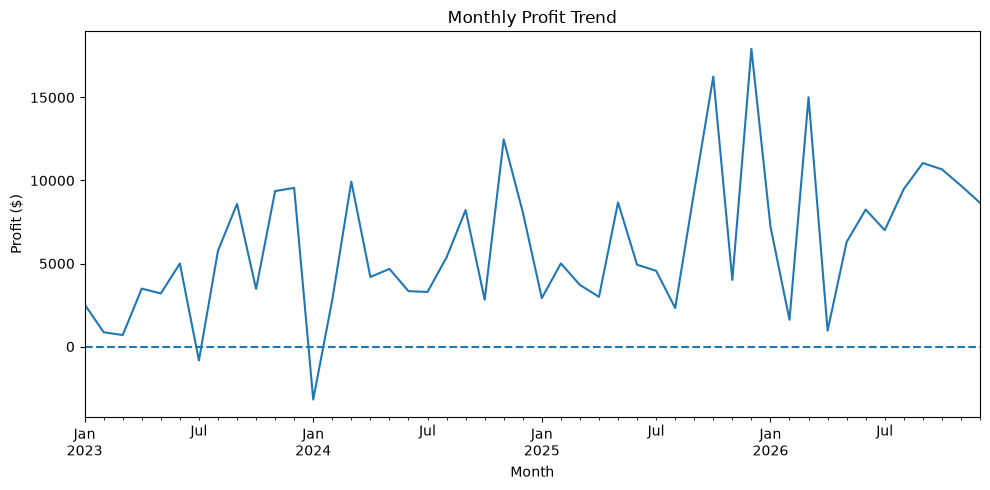

In [72]:
monthly_performance["Profit"].plot(
    kind="line",
    figsize=(10, 5),
    title="Monthly Profit Trend"
)

plt.axhline(0, linestyle="--")
plt.xlabel("Month")
plt.ylabel("Profit ($)")
plt.tight_layout()

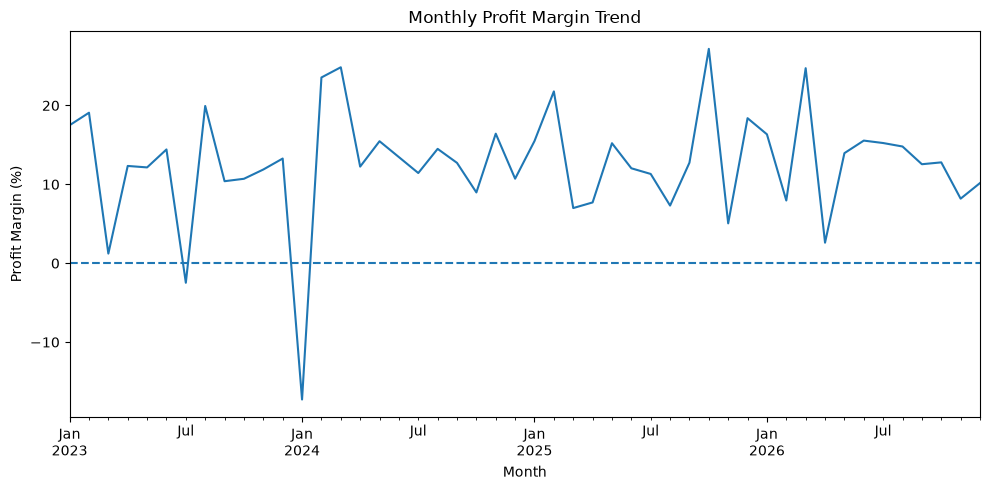

In [73]:
monthly_performance["Profit Margin"] = (
    monthly_performance["Profit"] / monthly_performance["Sales"] * 100
)

monthly_performance["Profit Margin"].plot(
    kind="line",
    figsize=(10, 5),
    title="Monthly Profit Margin Trend"
)

plt.axhline(0, linestyle="--")
plt.xlabel("Month")
plt.ylabel("Profit Margin (%)")
plt.tight_layout()